In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
from xgboost import XGBRegressor
import optuna

In [10]:
# 경고 메시지 무시
warnings.filterwarnings('ignore', category=FutureWarning)

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('data_updated.csv', encoding='utf-8')

In [11]:
# 5대 리그 필터링
top_5_leagues = ['Bundesliga', 'LaLiga', 'Premier League', 'Serie A', 'Ligue 1']
df = df[df['리그'].isin(top_5_leagues)].copy()

# 기본 전처리
df['TM_시장가치_EUR'] = pd.to_numeric(df['TM_시장가치_EUR'], errors='coerce')
# 'InjuryDays'도 숫자로 변환하고 결측치는 0으로 채움
df['InjuryDays'] = pd.to_numeric(df['InjuryDays'], errors='coerce').fillna(0)
df.dropna(subset=['TM_시장가치_EUR', '포지션'], inplace=True)
df = df[df['TM_시장가치_EUR'] > 0]
df = df[df['포지션'] != '골키퍼'].copy()


# 2. 피쳐 엔지니어링 (Feature Engineering)
df.sort_values(by=['name_key', '시즌'], inplace=True)

df['나이_제곱'] = df['시즌종료시점만나이'] ** 2

stats_for_change = ['득점', '어시스트', '기회 창출', '슛', '태클 성공', '가로채기', '터치', '성공한 패스']
for stat in stats_for_change:
    df[f'전시즌_{stat}'] = df.groupby('name_key')[stat].shift(1).fillna(0)
    df[f'{stat}_변화량'] = df[stat] - df[f'전시즌_{stat}']

df['나이x득점_변화량'] = (df['시즌종료시점만나이'] * df['득점_변화량'])
df['슛_대비_득점율'] = np.divide(df['득점'], df['슛'], out=np.zeros_like(df['득점'], dtype=float), where=df['슛']!=0)

df['전시즌_시장가치_EUR'] = df.groupby('name_key')['TM_시장가치_EUR'].shift(1).fillna(0)
df['log_전시즌_시장가치'] = np.log1p(df['전시즌_시장가치_EUR'])
df['log_현재_시장가치'] = np.log1p(df['TM_시장가치_EUR'])
df['시장가치_변화량'] = df['TM_시장가치_EUR'] - df['전시즌_시장가치_EUR']

In [12]:
# 3. 포지션 그룹핑
def group_position_detailed(pos):
    pos_str = str(pos)
    if '중앙 수비수' in pos_str: return '중앙 수비수'
    if '왼쪽 수비수' in pos_str or '오른쪽 수비수' in pos_str: return '측면 수비수'
    if '수비형 미드필더' in pos_str: return '수비형 미드필더'
    if '공격형 미드필더' in pos_str: return '공격형 미드필더'
    if '중앙 미드필더' in pos_str: return '중앙 미드필더'
    if '윙어' in pos_str or '왼쪽 미드필더' in pos_str or '오른쪽 미드필더' in pos_str: return '윙어'
    if '스트라이커' in pos_str: return '스트라이커'
    return '기타'
df['포지션_그룹'] = df['포지션'].apply(group_position_detailed)
df = df[df['포지션_그룹'] != '기타']

In [18]:
def objective(trial, group, X_train, y_train, X_val, y_val):
    
    if group == '스트라이커':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 900, 1500, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.04, log=True),
            'max_depth': trial.suggest_int('max_depth', 13, 19),
            'subsample': trial.suggest_float('subsample', 0.5, 0.85),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.2, 0.55),
        }
    elif group == '윙어':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 1300, 1900, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.12, log=True),
            'max_depth': trial.suggest_int('max_depth', 11, 17),
            'subsample': trial.suggest_float('subsample', 0.85, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.15, 0.45),
        }
    elif group == '공격형 미드필더':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 1200, 1800, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.05, log=True),
            'max_depth': trial.suggest_int('max_depth', 9, 15),
            'subsample': trial.suggest_float('subsample', 0.4, 0.8),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.7),
        }
    elif group == '중앙 미드필더':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 1300, 1900, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.07, 0.15, log=True),
            'max_depth': trial.suggest_int('max_depth', 6, 11),
            'subsample': trial.suggest_float('subsample', 0.7, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.7),
        }
    elif group == '수비형 미드필더':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 800, 1400, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.04, log=True),
            'max_depth': trial.suggest_int('max_depth', 12, 19),
            'subsample': trial.suggest_float('subsample', 0.2, 0.6),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.7),
        }
    elif group == '측면 수비수':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 900, 1500, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.03, log=True),
            'max_depth': trial.suggest_int('max_depth', 8, 14),
            'subsample': trial.suggest_float('subsample', 0.7, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.25, 0.6),
        }
    else: 
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 1300, 1900, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.04, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 9),
            'subsample': trial.suggest_float('subsample', 0.3, 0.7),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 0.35),
        }

    params.update({
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'random_state': 42,
        'n_jobs': -1,
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True)
    })
    
    model = XGBRegressor(**params)
    
    model.fit(X_train, y_train, 
              eval_set=[(X_val, y_val)],  
              verbose=False)
    
    preds = model.predict(X_val)
    r2 = r2_score(y_val, preds)
    return r2

In [19]:
champion_params_storage = {} # 각 그룹별 최적 파라미터 저장용

position_groups = sorted(df['포지션_그룹'].unique())
for group in position_groups:
    print("\n" + "="*80)
    print(f"✨ 포지션 그룹 최적화 (XGBoost + Optuna): {group} ✨")
    print("="*80)

    group_df = df[df['포지션_그룹'] == group].copy()
    if len(group_df) < 20: continue

    y = group_df['log_현재_시장가치']
    cols_to_drop = [
        '리그', 'TM_시장가치_EUR', '전시즌_시장가치_EUR', '시장가치_변화량', 'log_현재_시장가치',
        '선수명', '생년월일', 'source_file', 'name_key', '시즌', '시즌코드', 
        '포지션', '포지션_그룹'
    ] + [f'전시즌_{stat}' for stat in stats_for_change]
    X = group_df.drop(columns=cols_to_drop).fillna(0)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"'{group}' 포지션에 대한 Optuna 최적화를 시작합니다 (N_Trials=50)...")
    study = optuna.create_study(direction='maximize') 
    study.optimize(lambda trial: objective(trial, group, X_train_scaled, y_train, X_test_scaled, y_test), 
                   n_trials=40) 

    print("최적화 완료!")
    best_r2 = study.best_value
    best_params = study.best_params
    print(f"🏆 최적의 R-squared: {best_r2:.4f}")
    print(f"🚀 최적의 파라미터: {best_params}")
    
    # 최적 파라미터 저장
    champion_params_storage[group] = best_params

[I 2025-10-30 18:28:25,876] A new study created in memory with name: no-name-99900385-98dc-4766-9b4f-586561b57b40



✨ 포지션 그룹 최적화 (XGBoost + Optuna): 공격형 미드필더 ✨
'공격형 미드필더' 포지션에 대한 Optuna 최적화를 시작합니다 (N_Trials=50)...


[I 2025-10-30 18:28:31,765] Trial 0 finished with value: 0.7782340673882475 and parameters: {'n_estimators': 1700, 'learning_rate': 0.017444702326633345, 'max_depth': 9, 'subsample': 0.7380775454292238, 'colsample_bytree': 0.5661403131787924, 'reg_alpha': 0.007879515238572566, 'reg_lambda': 1.065747216015718e-08}. Best is trial 0 with value: 0.7782340673882475.
[I 2025-10-30 18:28:37,765] Trial 1 finished with value: 0.7916122957657085 and parameters: {'n_estimators': 1600, 'learning_rate': 0.02079030702903263, 'max_depth': 12, 'subsample': 0.682375487500958, 'colsample_bytree': 0.46392321948615206, 'reg_alpha': 5.5094709582305186e-06, 'reg_lambda': 0.002105360675273033}. Best is trial 1 with value: 0.7916122957657085.
[I 2025-10-30 18:28:40,102] Trial 2 finished with value: 0.7706405485566233 and parameters: {'n_estimators': 1400, 'learning_rate': 0.04696083368816723, 'max_depth': 10, 'subsample': 0.7963081405781303, 'colsample_bytree': 0.4522203862955867, 'reg_alpha': 2.3669298536448

최적화 완료!
🏆 최적의 R-squared: 0.7977
🚀 최적의 파라미터: {'n_estimators': 1600, 'learning_rate': 0.030422699720440077, 'max_depth': 11, 'subsample': 0.6446675519912621, 'colsample_bytree': 0.5002384795767655, 'reg_alpha': 0.01137409729039051, 'reg_lambda': 6.073480582562277e-05}

✨ 포지션 그룹 최적화 (XGBoost + Optuna): 수비형 미드필더 ✨
'수비형 미드필더' 포지션에 대한 Optuna 최적화를 시작합니다 (N_Trials=50)...


[I 2025-10-30 18:33:21,940] Trial 0 finished with value: 0.7417742882899405 and parameters: {'n_estimators': 1100, 'learning_rate': 0.010948618552309821, 'max_depth': 12, 'subsample': 0.5539029768450618, 'colsample_bytree': 0.4689336540930059, 'reg_alpha': 2.3997642076565348e-05, 'reg_lambda': 5.901391478562101e-06}. Best is trial 0 with value: 0.7417742882899405.
[I 2025-10-30 18:33:28,520] Trial 1 finished with value: 0.701085233054625 and parameters: {'n_estimators': 800, 'learning_rate': 0.03857056807910141, 'max_depth': 15, 'subsample': 0.3484378817766999, 'colsample_bytree': 0.583990282191114, 'reg_alpha': 0.05784879132148271, 'reg_lambda': 5.224882342233366e-07}. Best is trial 0 with value: 0.7417742882899405.
[I 2025-10-30 18:33:43,069] Trial 2 finished with value: 0.7340409653104465 and parameters: {'n_estimators': 1200, 'learning_rate': 0.011683368000178862, 'max_depth': 14, 'subsample': 0.40529311693257564, 'colsample_bytree': 0.5403632940302366, 'reg_alpha': 7.5860629314593

...

최적화 완료!
🏆 최적의 R-squared: 0.6836
🚀 최적의 파라미터: {'n_estimators': 1700, 'learning_rate': 0.10419614032148358, 'max_depth': 6, 'subsample': 0.88764716105825, 'colsample_bytree': 0.5969114031752056, 'reg_alpha': 3.7964870268448173e-06, 'reg_lambda': 0.6478173960435574}

✨ 포지션 그룹 최적화 (XGBoost + Optuna): 중앙 수비수 ✨
'중앙 수비수' 포지션에 대한 Optuna 최적화를 시작합니다 (N_Trials=50)...


[I 2025-10-30 19:01:21,141] Trial 0 finished with value: 0.7041995553324025 and parameters: {'n_estimators': 1300, 'learning_rate': 0.028622428466417337, 'max_depth': 6, 'subsample': 0.5100452688144582, 'colsample_bytree': 0.26613011145835663, 'reg_alpha': 0.00014978237508154766, 'reg_lambda': 8.321544734174811e-08}. Best is trial 0 with value: 0.7041995553324025.
[I 2025-10-30 19:01:26,490] Trial 1 finished with value: 0.7296755780965797 and parameters: {'n_estimators': 1400, 'learning_rate': 0.015734047592293667, 'max_depth': 7, 'subsample': 0.6190969365738981, 'colsample_bytree': 0.20063854782075602, 'reg_alpha': 5.62414701162105e-08, 'reg_lambda': 7.220224577718594e-07}. Best is trial 1 with value: 0.7296755780965797.
[I 2025-10-30 19:01:29,885] Trial 2 finished with value: 0.6861382010823263 and parameters: {'n_estimators': 1300, 'learning_rate': 0.03600288117911953, 'max_depth': 6, 'subsample': 0.6529470675117434, 'colsample_bytree': 0.3445848997690357, 'reg_alpha': 0.00798381151

최적화 완료!
🏆 최적의 R-squared: 0.7397
🚀 최적의 파라미터: {'n_estimators': 1300, 'learning_rate': 0.018795356846693555, 'max_depth': 5, 'subsample': 0.48433334667038386, 'colsample_bytree': 0.13299749004837963, 'reg_alpha': 0.8438955687786474, 'reg_lambda': 1.1171830245791953e-06}

✨ 포지션 그룹 최적화 (XGBoost + Optuna): 측면 수비수 ✨
'측면 수비수' 포지션에 대한 Optuna 최적화를 시작합니다 (N_Trials=50)...


[I 2025-10-30 19:03:53,480] Trial 0 finished with value: 0.7232204213122487 and parameters: {'n_estimators': 1300, 'learning_rate': 0.022040409128186632, 'max_depth': 10, 'subsample': 0.9013630443990654, 'colsample_bytree': 0.5047333888488488, 'reg_alpha': 0.0022432754435512577, 'reg_lambda': 0.027638310344735257}. Best is trial 0 with value: 0.7232204213122487.
[I 2025-10-30 19:04:07,019] Trial 1 finished with value: 0.7212109281927668 and parameters: {'n_estimators': 1500, 'learning_rate': 0.0173330722533379, 'max_depth': 10, 'subsample': 0.95981557083977, 'colsample_bytree': 0.31203388306636426, 'reg_alpha': 0.009758790158353908, 'reg_lambda': 0.001187186234168276}. Best is trial 0 with value: 0.7232204213122487.
[I 2025-10-30 19:04:20,088] Trial 2 finished with value: 0.7306287882351594 and parameters: {'n_estimators': 1100, 'learning_rate': 0.013225411401671385, 'max_depth': 10, 'subsample': 0.9403910080437484, 'colsample_bytree': 0.36117021527750115, 'reg_alpha': 1.24492830440034

최적화 완료!
🏆 최적의 R-squared: 0.7452
🚀 최적의 파라미터: {'n_estimators': 900, 'learning_rate': 0.02017663364023019, 'max_depth': 8, 'subsample': 0.8713792338776986, 'colsample_bytree': 0.43433084312126524, 'reg_alpha': 9.195828654206766e-08, 'reg_lambda': 1.6320172577572492e-06}



✨ 모든 포지션 최적화 완료! 최종 모델 학습 및 분석 시작 ✨

✨ 포지션 그룹 최종 분석 (Champion Model): 공격형 미드필더 ✨
'공격형 미드필더' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 79.49%
  - 평균 예측 오차 (RMSE): 9,678,743 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance          Feature
1     0.118091        예상 골 (xG)
2     0.073334  xG 유효 슈팅 (xGOT)
3     0.067297     예상 어시스트 (xA)
4     0.057839     log_전시즌_시장가치
5     0.040190           패스 정확도
6     0.032406               터치
7     0.030873           성공한 패스
8     0.024426            유효 슈팅
9     0.023393           터치_변화량
10    0.023219                슛
11    0.022216        나이x득점_변화량
12    0.021139        기회 창출_변화량
13    0.020727           드리블 성공
14    0.018304            나이_제곱
15    0.017927       성공한 패스_변화량


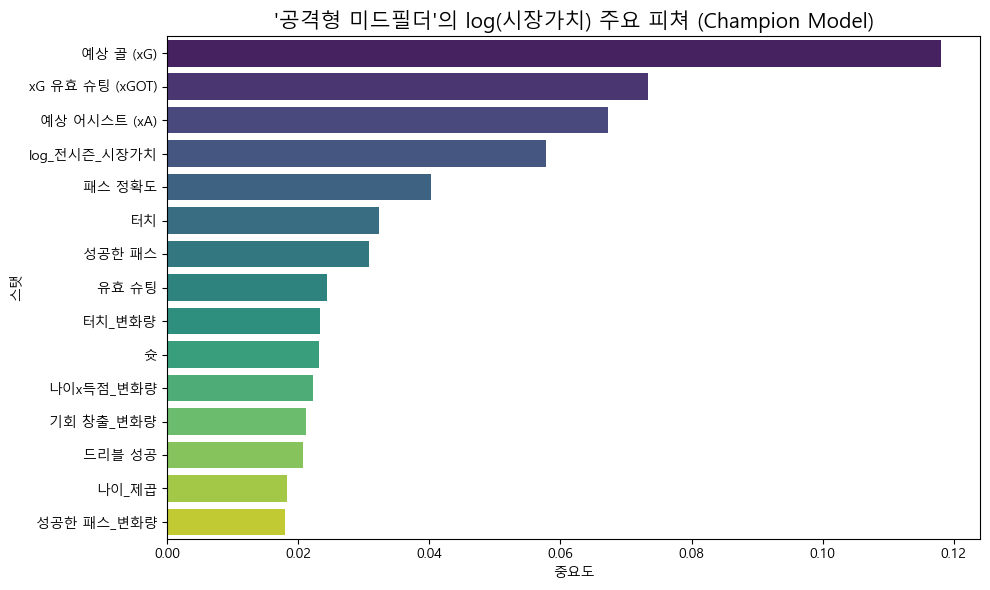


******************************
  예측 오차 심층 분석 - 공격형 미드필더
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                    선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
4121         joao félix         24    67500000.0   33333333.0   68525928.0   
8222  philippe coutinho         29    63000000.0   19500000.0   42370304.0   
1435        enzo millot         20           0.0    4750000.0   23438412.0   
3769   giovani lo celso         27    45000000.0   18000000.0   35654000.0   
2193       carlos soler         20           0.0    2866667.0   17661692.0   

       예측_오차_EUR  
4121  35192595.0  
8222  22870304.0  
1435  18688412.0  
3769  17654000.0  
2193  14795025.0  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                    선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
2810  philippe coutinho         26    42500000.0  120000000.0   47923648.0   
9269       paulo dybala         23           0.0   53333333.0   20974020.0   
2258    james rodriguez         25     

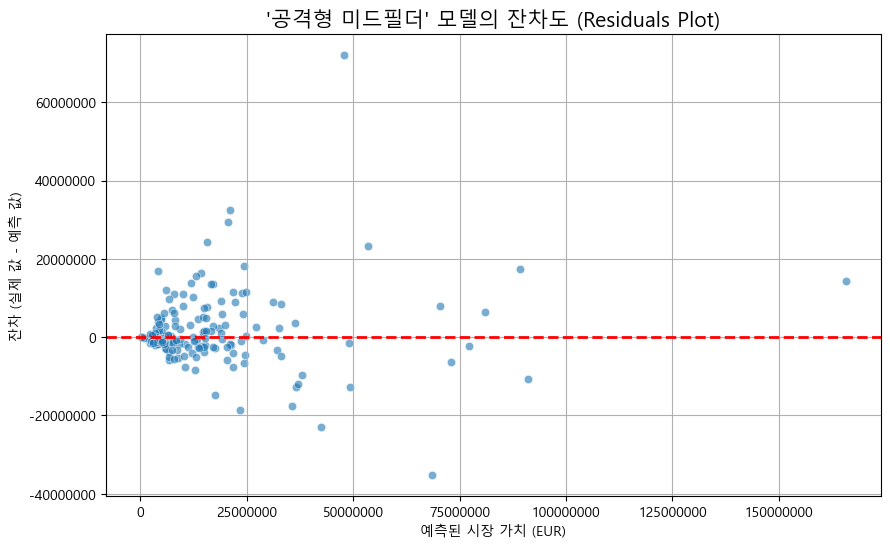


✨ 포지션 그룹 최종 분석 (Champion Model): 수비형 미드필더 ✨
'수비형 미드필더' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 74.92%
  - 평균 예측 오차 (RMSE): 7,737,523 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance       Feature
1     0.088817  예상 어시스트 (xA)
2     0.052657  log_전시즌_시장가치
3     0.046262        터치_변화량
4     0.044564    성공한 패스_변화량
5     0.043504        패스 정확도
6     0.040711            터치
7     0.035636        성공한 패스
8     0.030332     나이x득점_변화량
9     0.029972       크로스 정확도
10    0.025648       성공한 크로스
11    0.025189     볼 경합 성공 %
12    0.024805            퇴장
13    0.023106          어시스트
14    0.022059          볼 뺏김
15    0.021057     예상 골 (xG)


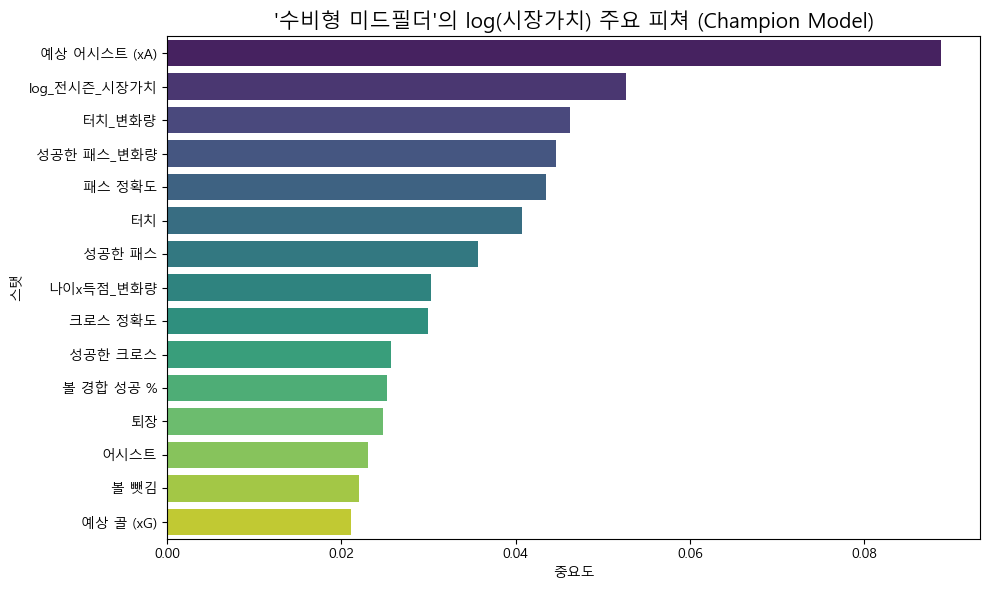


******************************
  예측 오차 심층 분석 - 수비형 미드필더
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                     선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
4216               pedri         21    96666667.0   83333333.0  122001400.0   
10662        harry winks         27    35000000.0   11000000.0   32637420.0   
4396     Frenkie de Jong         28    77500000.0   50000000.0   67754448.0   
4384   Eduardo Camavinga         22    93333333.0   70000000.0   86661736.0   
1270     marcel sabitzer         28    42000000.0   24000000.0   36512948.0   

        예측_오차_EUR  
4216   38668067.0  
10662  21637420.0  
4396   17754448.0  
4384   16661736.0  
1270   12512948.0  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                    선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
8761              rodri         27   115000000.0  115000000.0   72472016.0   
7615               fred         27           0.0   42000000.0   10786188.0   
6848  christian eriksen    

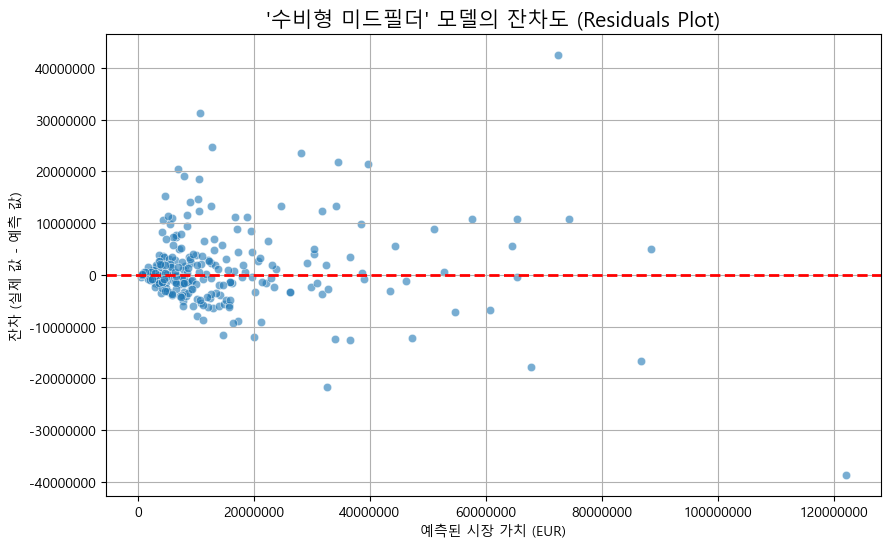


✨ 포지션 그룹 최종 분석 (Champion Model): 스트라이커 ✨
'스트라이커' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 71.27%
  - 평균 예측 오차 (RMSE): 9,729,788 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance         Feature
1     0.110025       예상 골 (xG)
2     0.072545    log_전시즌_시장가치
3     0.030798    예상 어시스트 (xA)
4     0.029847           유효 슈팅
5     0.029498       나이x득점_변화량
6     0.027825      성공한 패스_변화량
7     0.027430        슛_대비_득점율
8     0.026886          페널티 득점
9     0.026630          터치_변화량
10    0.026576          패스 정확도
11    0.026452  상대편 박스 내에서의 터치
12    0.025050        정확한 긴 패스
13    0.024803              득점
14    0.023768           슛_변화량
15    0.023603              터치


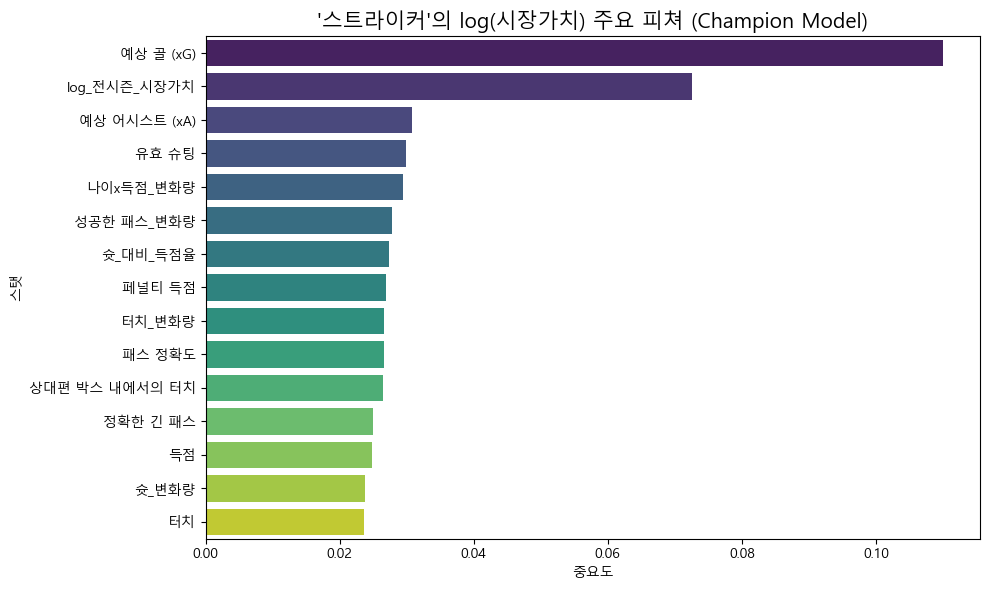


******************************
  예측 오차 심층 분석 - 스트라이커
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                  선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
4706    kylian mbappé         18           0.0   16333333.0   59652184.0   
4183    memphis depay         30    40000000.0   11000000.0   33321660.0   
2089      Myron Boadu         24    14666667.0    6333333.0   18604544.0   
4499  Mikel Oyarzabal         28    47500000.0   32500000.0   42519104.0   
8361       harry kane         29    95000000.0   90000000.0   99969896.0   

       예측_오차_EUR  
4706  43318851.0  
4183  22321660.0  
2089  12271211.0  
4499  10019104.0  
8361   9969896.0  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                  선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
745       kai havertz         20    61250000.0   85500000.0   40023532.0   
2106    Omar Marmoush         26    16750000.0   62500000.0   17299320.0   
6869      diego costa         28           0.0   50000000.0 

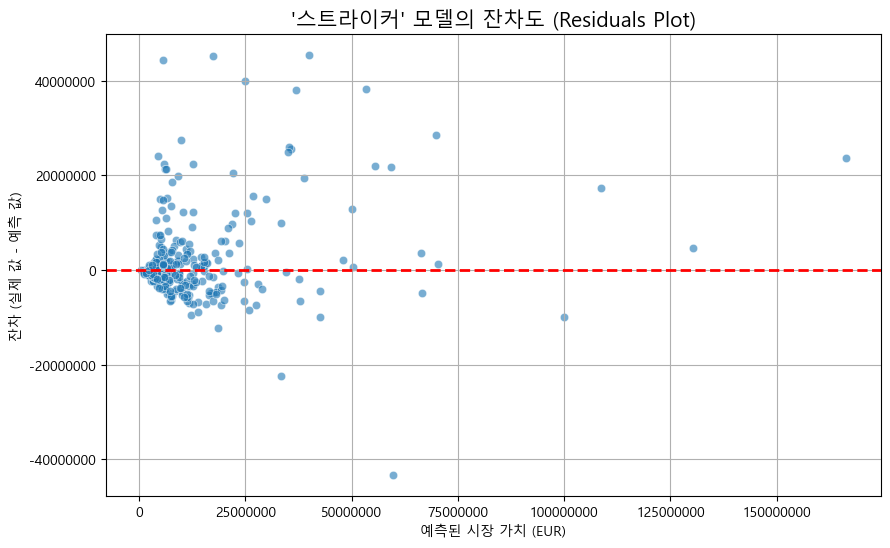


✨ 포지션 그룹 최종 분석 (Champion Model): 윙어 ✨
'윙어' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 70.22%
  - 평균 예측 오차 (RMSE): 8,730,924 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance         Feature
1     0.083723       예상 골 (xG)
2     0.074482  상대편 박스 내에서의 터치
3     0.040757            어시스트
4     0.038306          터치_변화량
5     0.033432           기회 창출
6     0.031166              터치
7     0.031077    log_전시즌_시장가치
8     0.029624    예상 어시스트 (xA)
9     0.028800           유효 슈팅
10    0.028350       기회 창출_변화량
11    0.026747              퇴장
12    0.025069              반칙
13    0.024680        슛_대비_득점율
14    0.024553              막힘
15    0.023631       PK 제외한 xG


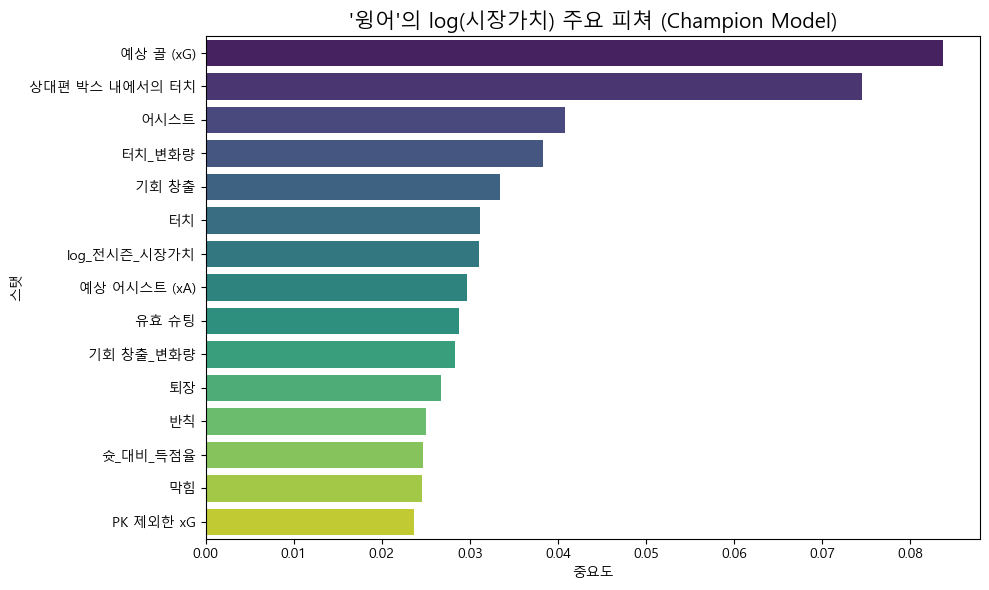


******************************
  예측 오차 심층 분석 - 윙어
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                    선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
7109        eden hazard         27    72500000.0  110000000.0  136559792.0   
7237       riyad mahrez         27    30000000.0   43333333.0   58251560.0   
7184         leroy sané         22    32500000.0   70000000.0   83901608.0   
8375      jack grealish         27    83333333.0   72500000.0   85499160.0   
3687  ander barrenetxea         21    13666667.0    6000000.0   17631972.0   

       예측_오차_EUR  
7109  26559792.0  
7237  14918227.0  
7184  13901608.0  
8375  12999160.0  
3687  11631972.0  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                         선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  \
4228                   rodri         24    85000000.0  115000000.0   
7725         raheem sterling         25   130000000.0  144000000.0   
10971  khvicha kvaratskhelia         23    66250000.0   80000000.0   

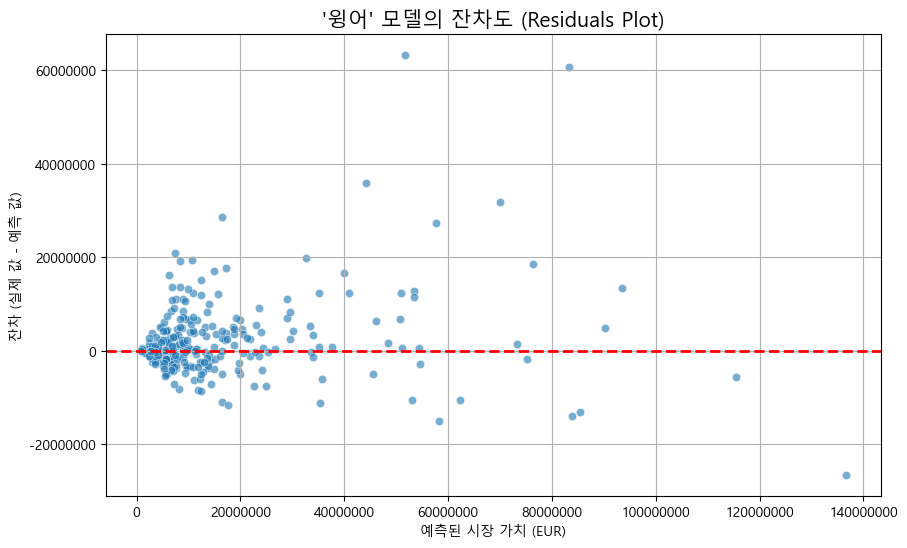


✨ 포지션 그룹 최종 분석 (Champion Model): 중앙 미드필더 ✨
'중앙 미드필더' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 67.68%
  - 평균 예측 오차 (RMSE): 7,887,799 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance       Feature
1     0.086341  log_전시즌_시장가치
2     0.065238  예상 어시스트 (xA)
3     0.059535        터치_변화량
4     0.057181          어시스트
5     0.050359        성공한 패스
6     0.037900         나이_제곱
7     0.025975     기회 창출_변화량
8     0.025663            터치
9     0.024649        패스 정확도
10    0.024246       볼 경합 성공
11    0.023733         태클 성공
12    0.023634     시즌종료시점만나이
13    0.021083     예상 골 (xG)
14    0.020950         유효 슈팅
15    0.020939    성공한 패스_변화량


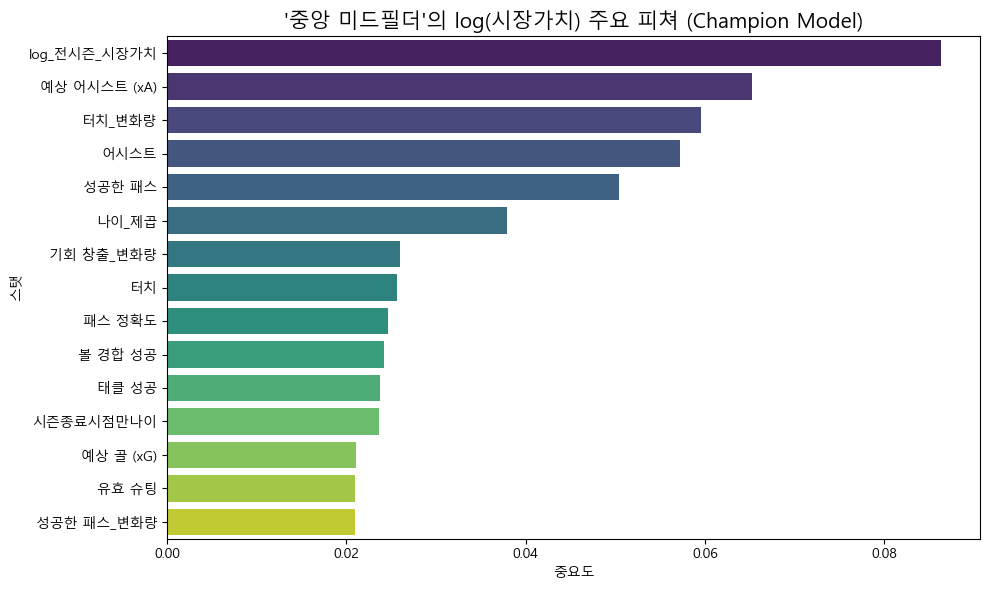


******************************
  예측 오차 심층 분석 - 중앙 미드필더
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                  선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
8135   james maddison         25    56666667.0   50000000.0   66621492.0   
7623     granit xhaka         27    47500000.0   31333333.0   47429596.0   
2452      fabián ruiz         22           0.0   14166667.0   30062128.0   
8189  martin ødegaard         23    38333333.0   43500000.0   59063916.0   
4534           Pepelu         26    14500000.0   12000000.0   25837092.0   

       예측_오차_EUR  
8135  16621492.0  
7623  16096263.0  
2452  15895461.0  
8189  15563916.0  
4534  13837092.0  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                     선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
5216     tanguy ndombélé         22    15000000.0   48750000.0   13460830.0   
6548  warren zaire-emery         18           0.0   56666667.0   21849460.0   
112           marco reus         28           0.0

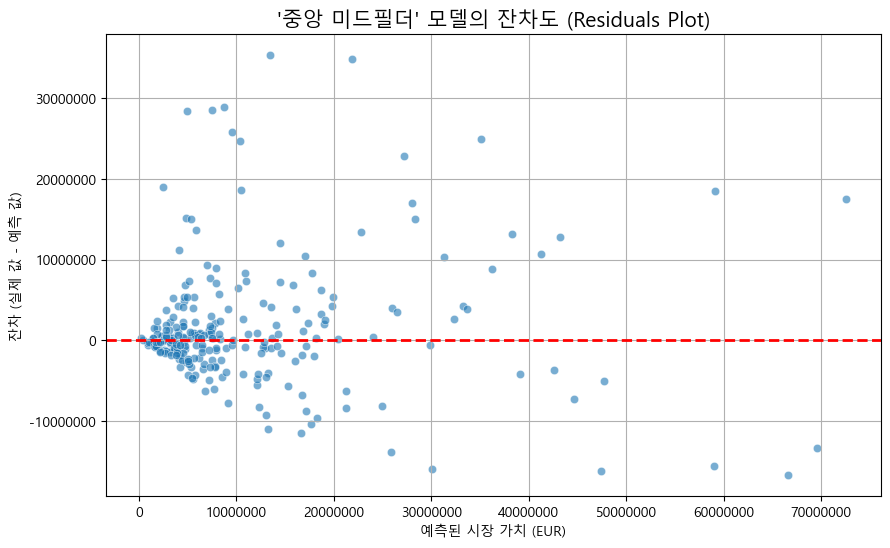


✨ 포지션 그룹 최종 분석 (Champion Model): 중앙 수비수 ✨
'중앙 수비수' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 74.28%
  - 평균 예측 오차 (RMSE): 8,158,838 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance          Feature
1     0.113884     log_전시즌_시장가치
2     0.078392            나이_제곱
3     0.066592        예상 골 (xG)
4     0.047955     예상 어시스트 (xA)
5     0.038274        시즌종료시점만나이
6     0.030021               터치
7     0.029512        PK 제외한 xG
8     0.026485           성공한 패스
9     0.026446           패스 정확도
10    0.022129           페널티 득점
11    0.021767  xG 유효 슈팅 (xGOT)
12    0.019435       성공한 패스_변화량
13    0.018591           터치_변화량
14    0.017781   상대편 박스 내에서의 터치
15    0.017772            유효 슈팅


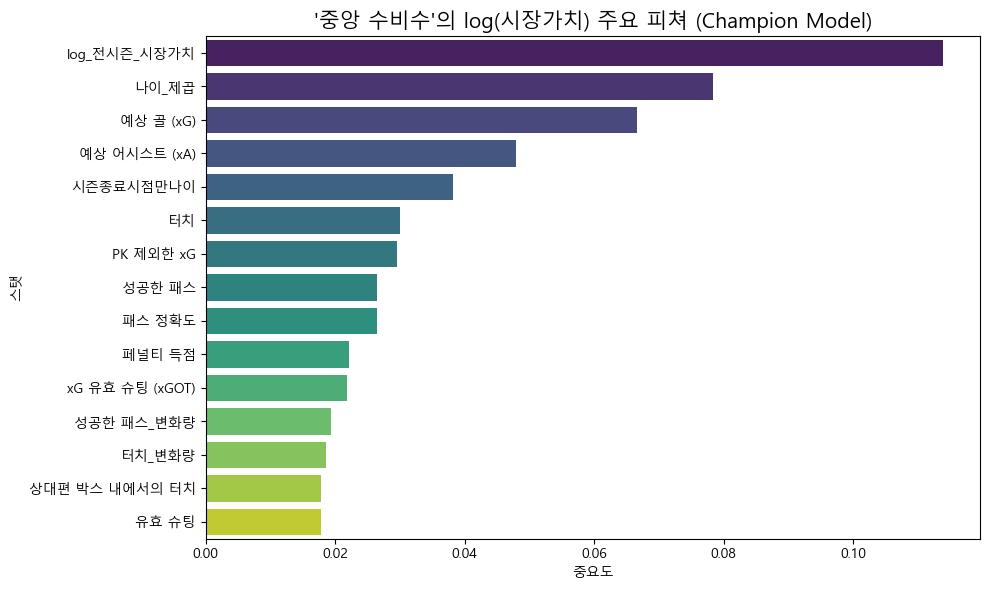


******************************
  예측 오차 심층 분석 - 중앙 수비수
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                  선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
7800  antonio rüdiger         28    45000000.0   27000000.0   48121128.0   
1003     malick thiaw         19           0.0    2125000.0   16597165.0   
8319  clément lenglet         27    35000000.0   11000000.0   25115356.0   
9257   milan skriniar         22           0.0    3500000.0   16565159.0   
1965        Eric Dier         31    24333333.0    8666667.0   21062980.0   

       예측_오차_EUR  
7800  21121128.0  
1003  14472165.0  
8319  14115356.0  
9257  13065159.0  
1965  12396313.0  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                       선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
7320              bernardo         24    28333333.0   76250000.0   26534592.0   
2214           diego godin         31           0.0   39000000.0    6089292.5   
3703   aurélien tchouaméni         23    450

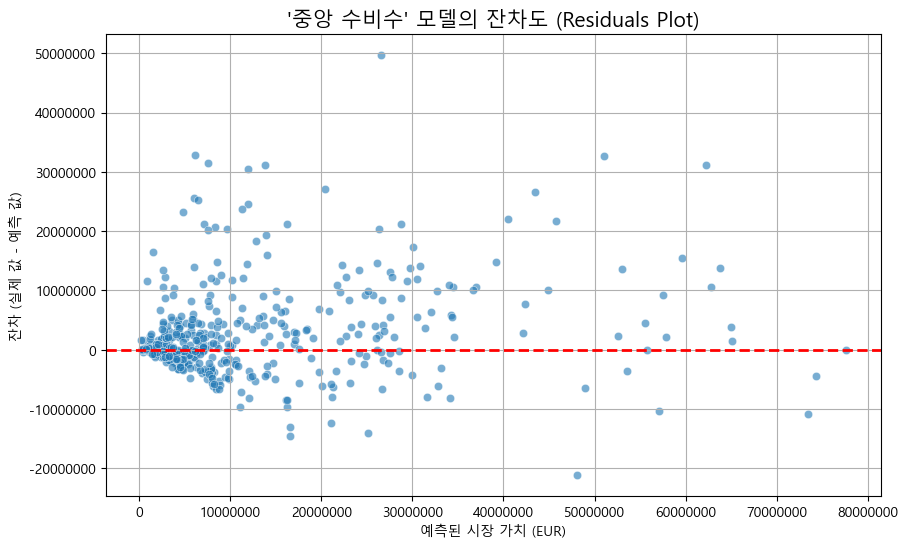


✨ 포지션 그룹 최종 분석 (Champion Model): 측면 수비수 ✨
'측면 수비수' 포지션의 최종 챔피언 모델을 학습합니다...

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 73.96%
  - 평균 예측 오차 (RMSE): 6,526,434 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance         Feature
1     0.070502    log_전시즌_시장가치
2     0.065553          페널티 득점
3     0.050409          성공한 패스
4     0.046350    예상 어시스트 (xA)
5     0.044390       예상 골 (xG)
6     0.042891              터치
7     0.040813  상대편 박스 내에서의 터치
8     0.032217      성공한 패스_변화량
9     0.028157              퇴장
10    0.027951          터치_변화량
11    0.027781          패스 정확도
12    0.023676           나이_제곱
13    0.021278           태클 성공
14    0.020322              반칙
15    0.018894        롱 패스 정확도


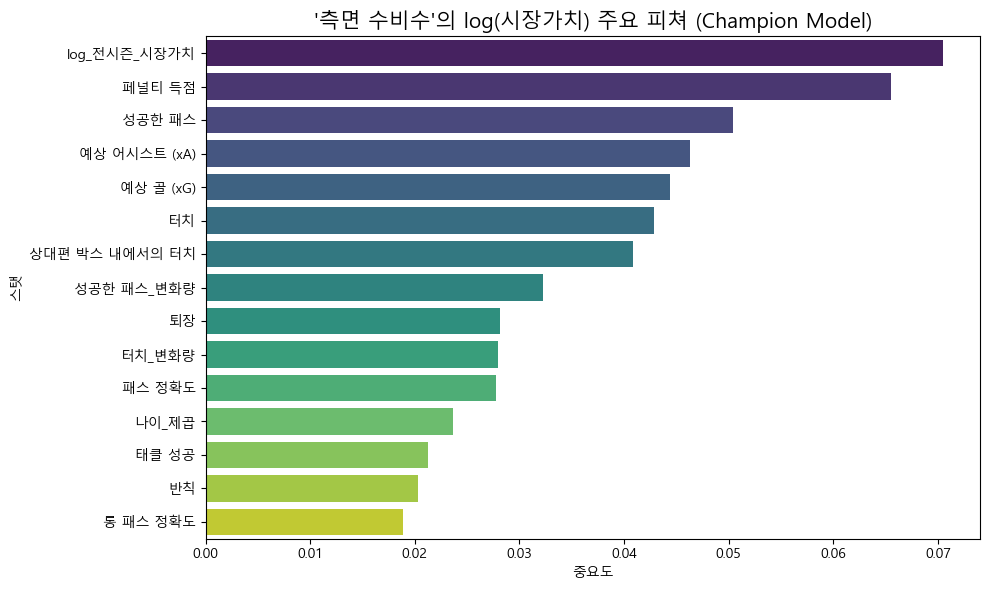


******************************
  예측 오차 심층 분석 - 측면 수비수
******************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                  선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
4070    ferland mendy         28    45000000.0   20666667.0   32715824.0   
3479  hector bellerin         27    27500000.0   20000000.0   29870596.0   
263      filip kostic         25     9000000.0    7000000.0   16738157.0   
1481     jonjoe kenny         26     9833333.0    3500000.0   12240456.0   
3602       renan lodi         24    36250000.0   25000000.0   33629668.0   

       예측_오차_EUR  
4070  12049157.0  
3479   9870596.0  
263    9738157.0  
1481   8740456.0  
3602   8629668.0  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                     선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
8954      jurrien timber         23           0.0   50000000.0    8625108.0   
8672      josko gvardiol         22    67500000.0   77500000.0   41718508.0   
1635  alejandro grimaldo         28           0.0 

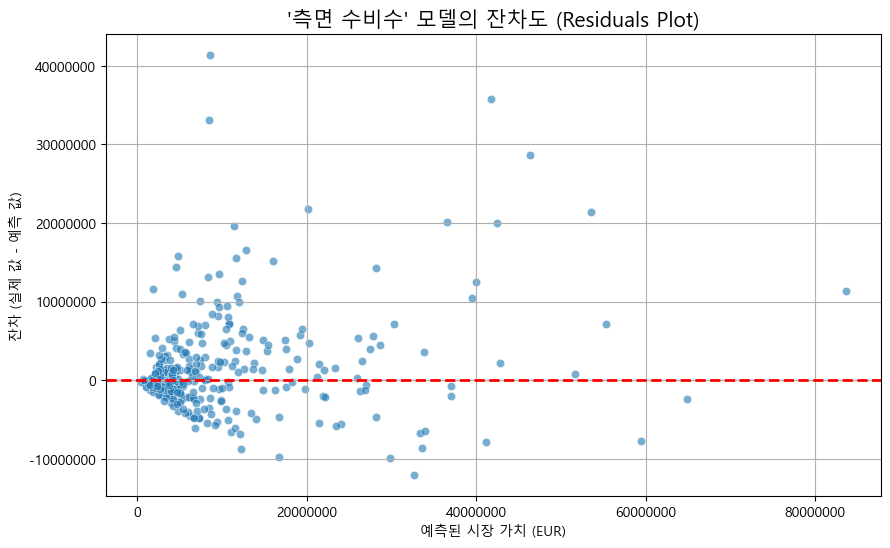

In [15]:
print("\n" + "="*80)
print("✨ 모든 포지션 최적화 완료! 최종 모델 학습 및 분석 시작 ✨")
print("="*80)

final_results_storage = {} # 최종 분석 결과 저장

for group in position_groups:
    # (이하 코드는 이전과 동일하며, champion_params_storage에서 새로운 파라미터를 가져와 사용합니다.)
    print("\n" + "="*80)
    print(f"✨ 포지션 그룹 최종 분석 (Champion Model): {group} ✨")
    print("="*80)

    group_df = df[df['포지션_그룹'] == group].copy()
    if len(group_df) < 20: continue
    
    y = group_df['log_현재_시장가치']
    cols_to_drop = [
        '리그', 'TM_시장가치_EUR', '전시즌_시장가치_EUR', '시장가치_변화량', 'log_현재_시장가치',
        '선수명', '생년월일', 'source_file', 'name_key', '시즌', '시즌코드', 
        '포지션', '포지션_그룹'
    ] + [f'전시즌_{stat}' for stat in stats_for_change]
    X = group_df.drop(columns=cols_to_drop).fillna(0)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"'{group}' 포지션의 최종 챔피언 모델을 학습합니다...")
    champion_params = champion_params_storage.get(group) # 저장된 최적 파라미터 로드
    if not champion_params:
        print(f"'{group}'에 대한 최적 파라미터를 찾을 수 없어 건너뜁니다.")
        continue
    
    final_model = XGBRegressor(objective='reg:squarederror', **champion_params, random_state=42, n_jobs=-1)
    final_model.fit(X_train_scaled, y_train, verbose=False)

    # --- 최종 모델 평가 및 오차 분석 ---
    log_y_pred = final_model.predict(X_test_scaled)
    y_pred = np.expm1(log_y_pred)
    y_test_orig = np.expm1(y_test)
    
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    r2 = r2_score(y_test, log_y_pred) 
    
    print(f"\n[📊 **챔피언 모델** 성능 평가]")
    print(f"  - 모델 설명력 (R-squared): {r2:.2%}")
    print(f"  - 평균 예측 오차 (RMSE): {rmse:,.0f} EUR")

    # (이후 피쳐 중요도, 오차 분석, 잔차도 코드는 동일)
    importances = final_model.feature_importances_
    feature_names = X.columns
    imp_df = pd.DataFrame(sorted(zip(importances, feature_names), reverse=True), columns=['Importance', 'Feature']).head(15)
    print(f"\n[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]")
    imp_df_display = imp_df.copy()
    imp_df_display.index = np.arange(1, len(imp_df_display) + 1)
    print(imp_df_display)
    plt.figure(figsize=(10, 6)); sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis'); plt.title(f"'{group}'의 log(시장가치) 주요 피쳐 (Champion Model)", fontsize=15); plt.xlabel('중요도'); plt.ylabel('스탯'); plt.tight_layout(); plt.show()
    results_df = X_test.copy(); results_df['선수명'] = df.loc[X_test.index, '선수명']; results_df['전시즌_시장가치_EUR'] = df.loc[X_test.index, '전시즌_시장가치_EUR']; results_df['실제_시장가치_EUR'] = y_test_orig; results_df['예측_시장가치_EUR'] = pd.Series(y_pred, index=X_test.index); results_df['예측_오차_EUR'] = results_df['예측_시장가치_EUR'] - results_df['실제_시장가치_EUR']; analysis_cols = ['선수명', '시즌종료시점만나이', '전시즌_시장가치_EUR', '실제_시장가치_EUR', '예측_시장가치_EUR', '예측_오차_EUR']; error_analysis_df = results_df[analysis_cols].copy(); print("\n" + "*"*30); print(f"  예측 오차 심층 분석 - {group}"); print("*"*30); print("\n[⬆️ 모델이 가장 과대평가한 선수 TOP 5]"); print(error_analysis_df.sort_values(by='예측_오차_EUR', ascending=False).head(5)); print("\n[⬇️ 모델이 가장 과소평가한 선수 TOP 5]"); print(error_analysis_df.sort_values(by='예측_오차_EUR', ascending=True).head(5)); print("\n[🎯 모델이 가장 정확하게 예측한 선수 TOP 5]"); most_accurate = error_analysis_df.copy(); most_accurate['절대오차'] = most_accurate['예측_오차_EUR'].abs(); print(most_accurate.sort_values(by='절대오차', ascending=True).head(5).drop(columns='절대오차'));
    residuals = y_test_orig - y_pred; plt.figure(figsize=(10, 6)); sns.scatterplot(x=y_pred, y=residuals, alpha=0.6); plt.axhline(y=0, color='r', linestyle='--', lw=2); plt.title(f"'{group}' 모델의 잔차도 (Residuals Plot)", fontsize=15); plt.xlabel("예측된 시장 가치 (EUR)"); plt.ylabel("잔차 (실제 값 - 예측 값)"); plt.ticklabel_format(style='plain', axis='both'); plt.grid(True); plt.show()